In [1]:
from raft.raft_member import Member
from raft.raft_mesh import platformMesh, sPlatformMesh
import yaml
import numpy as np
import moorpy as mp

fname_design ="examples/VolturnUS-S_example.yaml"

    # fname_design = f"tests/test_data/{list_files[0]}"

with open(fname_design) as file:
    design = yaml.load(file, Loader=yaml.FullLoader)


moor = mp.System()
moor.parseYAML(design['mooring'])

# ensure proper setup with one coupled Body tied to this FOWT
if len(moor.bodyList) == 0:
    moor.addBody(-1, [0,0,0,0,0,0]) # create a new body if needed
    for point in moor.pointList:
        if point.type == -1:  # attached any coupled points to the body
            moor.bodyList[0].attachPoint(point.number, point.r)
            point.type = 1  # now indicate point is fixed (to the body)
            
elif len(moor.bodyList) == 1:
    moor.bodyList[0].type = -1  # ensure it's set to coupled type
else:
    raise Exception("More than one body detected in FOWT mooring system.")
    
# move mooring system according to the FOWT's reference position

moor.initialize()

[[ 7.72116014e+04  5.83444563e-02 -1.58284576e+01 -5.01341727e-01
   1.24690331e+06 -1.75028874e-01]
 [ 5.83444563e-02  7.74764196e+04 -4.57460554e-02 -1.23771445e+06
   5.09813219e-01  1.35461655e+04]
 [-1.58284576e+01 -4.57460554e-02  6.64535399e+04  3.64994160e-01
  -9.39313965e+02 -8.47149175e-03]
 [-5.01341727e-01 -1.23771445e+06  3.64994160e-01  2.80851944e+08
  -7.63198237e+01 -1.35782666e+05]
 [ 1.24690331e+06  5.09813219e-01 -9.39313965e+02 -7.58552402e+01
   2.81869312e+08  5.78903366e+01]
 [-1.75028874e-01  1.35461655e+04 -8.47149175e-03 -2.21604561e+05
   3.78185906e+01  2.72253791e+08]]
boydForce=[-2.50544334e+05  4.82794546e+05 -6.93424395e+06 -1.09991682e+08
  1.90688232e+06  2.90916107e+06]


FigureCanvasAgg is non-interactive, and thus cannot be shown

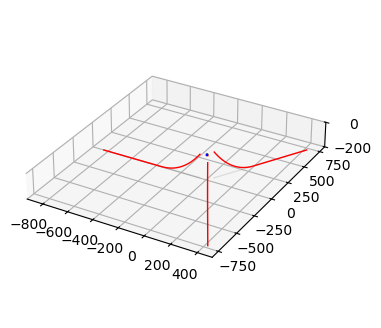

In [5]:
moor.initialize()

moor.bodyList[0].setPosition([0,0,0,0,0,0])
moor.solveEquilibrium()                                       # equilibrate
# fig, ax = moor.plot()  



C = moor.getCoupledStiffnessA()
# C_ = moor.getCoupledStiffness()
print(C)

moor.bodyList[0].setPosition([5,0,0,np.pi/8,0,0])
moor.solveEquilibrium()  
fig, ax = moor.plot(color='red') 
fig.show()

F = moor.bodyList[0].getForces()

print(f"boydForce={F}")
# print(C_)


# moor.bodyList[0].f6Ext = np.array([0, 0, 1e6, 0, 0, 0])       # apply an external force on the body
# moor.solveEquilibrium3()                                      # equilibrate
# fig, ax = moor.plot(ax=ax, color='red') 
# F = moor.bodyList[0].getForces()
# R = moor.lineList[1].getPosition(800)
# print(F)
# print(R)

In [3]:
fruits = ['apple', 'banana', 'cherry']

cars = ['Ford', 'BMW', 'Volvo']

fruits.extend(cars)
print(fruits)

['apple', 'banana', 'cherry', 'Ford', 'BMW', 'Volvo']


In [5]:
nBlades = 3
import numpy as np
list(np.arange(nBlades) * 360. / nBlades)

[0.0, 120.0, 240.0]